In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv(r"C:\Users\USER\Downloads\digit-recognizer\train.csv")

In [3]:
data.shape

(42000, 785)

In [4]:
data.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [5]:
# 1. Converting dataframe to array, splitting into train and test set and transposing

data = np.array(data) # converting to numpy array
m, n = data.shape # Extracting number of samples (m) and number of features (n)
np.random.shuffle(data) # Re-organizing and rearranging data for randomness

test_data = data[0:1000].T # Extracting test data and transposing; picking first 1000 samples and making columns row and row columns for matrix dot multiplication (Transposing)
X_test = test_data[1:n] # Extracting Features (X) that will be used for (testing)
y_test = test_data[0] # Extracting the label transposed row

data_train = data[1000:m].T # Extracting train data and transposing; picking (49,000) samples and making columns row and row columns for matrix dot multiplication (Transposing)
X_train = data_train[1:n] # Extracting Features (X) that will be used for (training)
y_train = data_train[0] # Extracting the label transposed row

In [6]:
print(y_train.shape)
print(X_train[:, 0].shape)

(41000,)
(784,)


In [7]:
# 2. Initializing weights and bias

def init_params():
    # W1: 10 neurons, each receiving 784 input features
    w1 = np.random.randn(10, 784) * 0.01 
    # b1: 1 bias term for each of the 10 neurons in the hidden layer
    b1 = np.zeros((10, 1)) 

    # W2: 10 output neurons, each receiving 10 inputs from the hidden layer
    w2 = np.random.randn(10, 10) * 0.01 
    # b2: 1 bias term for each of the 10 neurons in the output layer
    b2 = np.zeros((10, 1))
    
    return w1, b1, w2, b2 # Returns all needed parameters for calculation of predictions

In [8]:
# 3. Setting up ReLU

def ReLU(z):
    # Defining Relu
    # For each of the output of z, if the values are negative give it as 0
    return np.maximum(0, z)

In [9]:
# 4. Softmax activation function

def softmax(z):

    # Picks the exponential of the total 10 neurons
    exp_z = np.exp(z - np.max(z, axis=0, keepdims=True))

    # return the probability of each neurons
    return exp_z / np.sum(exp_z, axis=0, keepdims=True)

In [10]:
# 5. Forward pass function

def forward_pass(w1, b1, w2, b2, x):
    # Execution of the formular "Y = wx + b"
    
    # First Layer output calculation
    z1 = w1.dot(x) + b1
    
    # Output passing through ReLU activation function
    a1 = ReLU(z1)
    
    # Output layer outputs (logits)
    z2 = w2.dot(a1) + b2
    
    # Softmax giving us the class with the highest probability
    a2 = softmax(z2)

    # Returns all outputs for effective calculation of Back Propagation
    return z1, a1, z2, a2

In [11]:
# 1. Convert labels to one hot encoded values

def one_hot(y):
    # creates a matrix of 0s with rows of the training data rows and columns of the highest value of the label
    one_hot_y = np.zeros((y.size, y.max()+1))

    # It looks at each row, then uses y as a column index, if y exists, it changes that particular column index to 1
    one_hot_y[np.arange(y.size), y] = 1 
    
    # Transpose it, then each row will be a column for effective error calculation
    one_hot_y = one_hot_y.T

    # if label is 3, output will be [0, 0, 0, 1, 0, 0, 0, 0, 0, 0]
    return one_hot_y

In [12]:
# 2. Derivative of ReLU
def deriv_ReLU(z):

    # Catching the outputs that contributed to the error
    return z > 0

In [13]:
# 3. Backward Pass Function: Calculating how to adjust weights to reduce error

def backward_pass(z1, a1, z2, a2, w2, x, y):
    # Get total number of samples to average the error across the entire samples
    m = y.size
    
    # Transform integer labels into one hot probability matrix (e.g., [0,0,0,1...])
    one_hot_y = one_hot(y)

    # Calculate error (dz2): Find the difference between our Softmax predictions and the actual probability matrix
    dz2 = a2 - one_hot_y

    # Calculate Weight 2 Change (dw2): Determine how much each Output neuron's weight contributed to the error
    dw2 = 1/m * dz2.dot(a1.T)

    # Calculate Bias 2 Change (db2): Find the average error offset for the output layer
    db2 = 1/m * np.sum(dz2, axis=1, keepdims=True)

    # Calculate error for the Hidden Layer (dz1):
    
    # Use the Derivative of ReLU to "locate" only the neurons that were active (not 0) during the forward pass
    dz1 = w2.T.dot(dz2) * deriv_ReLU(z1)

    # Calculate Weight 1 Change (dw1): Determine how the input features influenced the hidden layer's error
    dw1 = 1/m * dz1.dot(x.T)
    
    # Calculate Bias 1 Change (db1): Find the average error offset for the hidden layer
    db1 = 1/m * np.sum(dz1, axis=1, keepdims=True)
    
    return dw1, db1, dw2, db2

In [31]:
# Update Parameters

def update_params(w1, b1, w2, b2, dw1, db1, dw2, db2, lr):

    # For the hidden layer
    w1 = w1 - lr * dw1
    b1 = b1 - lr * db1

    # For the output layer
    w2 = w2 - lr * dw2
    b2 = b2 - lr * db2

    return w1, b1, w2, b2

In [32]:
# Measure accuracy

def get_pred(a2):
    # Returns the index of the highest probability
    return np.argmax(a2, 0)


def get_accuracy(predictions, y):
    # Compares them
    print(predictions, y)
    # Return the correctly predicted / total dataset size percentage (Accuracy)
    return np.sum(predictions == y) / y.size

In [33]:
# Model Training

def train(x, y, iterations, lr):
    # Initialize parameters
    w1, b1, w2, b2 = init_params()

    # Start loop
    for i in range(iterations):
        # Model Tries to predict
        z1, a1, z2, a2 = forward_pass(w1, b1, w2, b2, x)
        # Checks how wrong it is
        dw1, db1, dw2, db2 = backward_pass(z1, a1, z2, a2, w2, x, y)
        # Correct the prediction by giving another parameters to try
        w1, b1, w2, b2 = update_params(w1, b1, w2, b2, dw1, db1, dw2, db2, lr)
        # Print Accuracy Overtime
        print(f"Epochs: {i+1}, Accuracy: {get_accuracy(get_pred(a2), y)}")
    return w1, b1, w2, b2

In [34]:
w1, b1, w2, b2 = train(X_train, y_train, 100, 0.001)

[1 8 1 ... 8 0 1] [0 9 6 ... 4 3 6]
Epochs: 1, Accuracy: 0.10465853658536585
[1 0 1 ... 0 0 1] [0 9 6 ... 4 3 6]
Epochs: 2, Accuracy: 0.13858536585365855
[1 0 1 ... 0 0 1] [0 9 6 ... 4 3 6]
Epochs: 3, Accuracy: 0.16617073170731708
[1 0 1 ... 0 0 1] [0 9 6 ... 4 3 6]
Epochs: 4, Accuracy: 0.18692682926829268
[0 0 1 ... 0 0 1] [0 9 6 ... 4 3 6]
Epochs: 5, Accuracy: 0.20621951219512194
[0 0 1 ... 0 0 1] [0 9 6 ... 4 3 6]
Epochs: 6, Accuracy: 0.22285365853658537
[0 0 1 ... 0 0 1] [0 9 6 ... 4 3 6]
Epochs: 7, Accuracy: 0.23980487804878048
[0 0 1 ... 0 0 1] [0 9 6 ... 4 3 6]
Epochs: 8, Accuracy: 0.2554390243902439
[0 0 1 ... 0 0 1] [0 9 6 ... 4 3 6]
Epochs: 9, Accuracy: 0.271
[0 0 1 ... 0 0 1] [0 9 6 ... 4 3 6]
Epochs: 10, Accuracy: 0.2839512195121951
[0 0 1 ... 0 0 1] [0 9 6 ... 4 3 6]
Epochs: 11, Accuracy: 0.29536585365853657
[0 0 2 ... 0 0 2] [0 9 6 ... 4 3 6]
Epochs: 12, Accuracy: 0.30997560975609756
[0 0 2 ... 0 0 2] [0 9 6 ... 4 3 6]
Epochs: 13, Accuracy: 0.32382926829268294
[0 0 2 ... 

In [45]:
# Making a prediction

def make_pred(x, w1, b1, w2, b2):
    # Makes a prediction
    _, _, _, a2 = forward_pass(w1, b1, w2, b2, x)
    # Get the output index
    predictions = get_pred(a2)
    return predictions


def test_pred(index, w1, b1, w2, b2):
    # Grap the image we are trying to predict in the test set
    current_image = X_test[:, index, None]
    # Make predictions
    prediction = make_pred(X_test[:, index, None], w1, b1, w2, b2)
    
    # Extract true value
    label = y_test[index]
    print("Prediction: ", prediction)
    print("Label: ", label)

    # Convert Image to Gray Scale
    current_image = current_image.reshape((28, 28)) * 255
    plt.gray()
    plt.imshow(current_image, interpolation="nearest")
    plt.show()

Prediction:  [5]
Label:  5


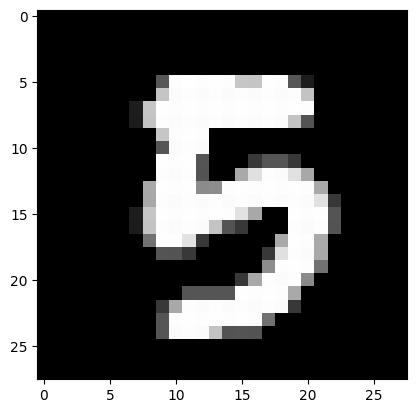

In [48]:
test_pred(1, w1, b1, w2, b2)

In [44]:
dev_pred = make_pred(X_dev, w1, b1, w2, b2)
get_accuracy(dev_pred, y_dev)

[6 1 2 8 9 2 4 7 7 0 3 2 3 8 0 3 1 0 5 2 8 8 0 7 8 5 9 7 9 1 5 7 3 7 5 7 0
 1 7 2 2 0 3 7 7 9 1 0 6 0 9 8 8 1 1 5 0 1 1 8 2 7 8 0 7 7 2 2 5 9 3 0 0 7
 5 8 3 5 3 5 7 2 0 2 9 4 6 3 2 3 0 1 8 8 6 8 7 8 3 3 6 7 3 1 7 1 8 0 9 2 7
 9 2 3 8 7 1 6 0 8 5 8 7 6 2 8 6 0 8 7 2 1 7 9 2 3 7 2 1 9 9 9 6 8 1 0 4 0
 0 2 8 0 1 7 1 0 8 2 6 7 7 4 1 7 5 1 1 9 2 1 3 0 1 8 4 0 2 9 6 1 0 8 8 8 1
 9 8 3 9 9 5 7 6 3 7 1 8 1 7 2 4 5 1 1 3 3 7 5 4 7 4 2 5 9 8 2 6 2 7 4 8 8
 1 7 0 0 4 5 2 6 9 2 3 0 2 1 2 0 4 1 2 6 6 8 2 1 9 3 0 6 1 2 3 9 9 0 1 3 2
 0 0 0 3 6 5 8 5 0 1 6 5 6 6 5 7 7 1 1 4 7 8 2 4 6 8 9 7 2 9 6 6 0 1 8 2 0
 7 7 8 3 5 8 5 1 7 8 1 9 4 6 2 9 8 8 9 4 7 5 9 6 3 9 2 3 3 6 9 0 0 6 4 6 5
 1 3 9 1 2 4 5 3 9 0 7 0 4 0 6 7 0 5 5 0 7 8 3 5 1 0 0 9 3 8 6 0 1 0 1 7 1
 4 5 9 8 1 1 6 7 2 7 6 9 2 7 7 1 0 9 0 2 4 5 7 4 3 6 0 8 9 7 5 5 1 0 7 0 7
 9 9 7 4 9 3 7 9 9 1 1 4 6 4 9 3 8 1 9 4 7 8 4 2 3 2 0 6 1 7 9 6 6 7 7 2 0
 3 5 3 7 2 2 6 9 8 8 6 8 9 7 9 8 9 9 7 7 1 7 8 5 7 6 3 6 1 1 8 9 3 3 1 1 2
 6 5 3 6 7 7 2 7 0 7 3 0 

np.float64(0.847)

In [49]:
w1

array([[ 0.01811563, -0.00802469,  0.00580427, ...,  0.00053706,
         0.00440457, -0.01400553],
       [-0.01568523, -0.00678745,  0.00878373, ...,  0.00251047,
         0.02181285,  0.00183183],
       [ 0.01313273,  0.00248192,  0.00589341, ..., -0.00066226,
        -0.00401216,  0.00200162],
       ...,
       [-0.00427036,  0.00496342,  0.00265449, ..., -0.02516496,
        -0.00812087,  0.00680862],
       [-0.00442698, -0.01554275, -0.02743191, ...,  0.00689519,
        -0.00691078, -0.01426823],
       [ 0.00284486,  0.00152495, -0.00326035, ...,  0.00501091,
         0.01141218,  0.01305593]], shape=(10, 784))

In [30]:
x = np.array([[1, 3, 6, 1, 4, 3, 2]])
exp_x = np.exp(x - np.max(x, axis=1, keepdims=True))
exp_x

array([[0.00673795, 0.04978707, 1.        , 0.00673795, 0.13533528,
        0.04978707, 0.01831564]])

array([[1., 1., 1., 1., 1., 1., 1.]])